In [ ]:
# Data collection command:
# `python comet_download.py --project=stationary-binary-regression --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
save_path = 'figures/'
config_data_path = 'data/stationary-binary-regression_params.csv'
run_data_path = 'data/stationary-binary-regression_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

for cfg in config_dfs.values():
    if "jax_jit_cache_dir" in cfg.columns:
        cfg.drop(columns=["jax_jit_cache_dir"], inplace=True)

{k: len(v) for k, v in config_dfs.items()}

{'autostep': 600, 'sgd_layerwise_step_size': 480}

In [7]:
print("_____Best Hyperparameter Configurations_____")
best_config_dfs, best_run_dfs = get_best_ablation_values(
    config_dfs, run_dfs,
    sweep_split_vars = {
        'autostep': ['model.n_layers', 'model.activation'],
        'sgd_layerwise_step_size': ['model.n_layers', 'model.activation'],
    })

_____Best Hyperparameter Configurations_____

=== autostep ===

Configuration: model.n_layers=2 | model.activation=ltu | # runs: 5
  Best optimizer.meta_learning_rate=${eval:2**-4}
  Best optimizer.learning_rate=${eval:2**2}

Configuration: model.n_layers=2 | model.activation=swish | # runs: 5
  Best optimizer.meta_learning_rate=${eval:2**-4}
  Best optimizer.learning_rate=${eval:2**-2}

Configuration: model.n_layers=3 | model.activation=ltu | # runs: 5
  Best optimizer.meta_learning_rate=${eval:2**-4}
  Best optimizer.learning_rate=${eval:2**2}

Configuration: model.n_layers=3 | model.activation=swish | # runs: 5
  Best optimizer.meta_learning_rate=${eval:2**-6}
  Best optimizer.learning_rate=${eval:2**-2}


=== sgd_layerwise_step_size ===

Configuration: model.n_layers=2 | model.activation=ltu | # runs: 5
  Best optimizer.learning_rate=${eval:2**-18}
  Best representation_optimizer.learning_rate=${eval:2**2}

Configuration: model.n_layers=2 | model.activation=swish | # runs: 5
  Best

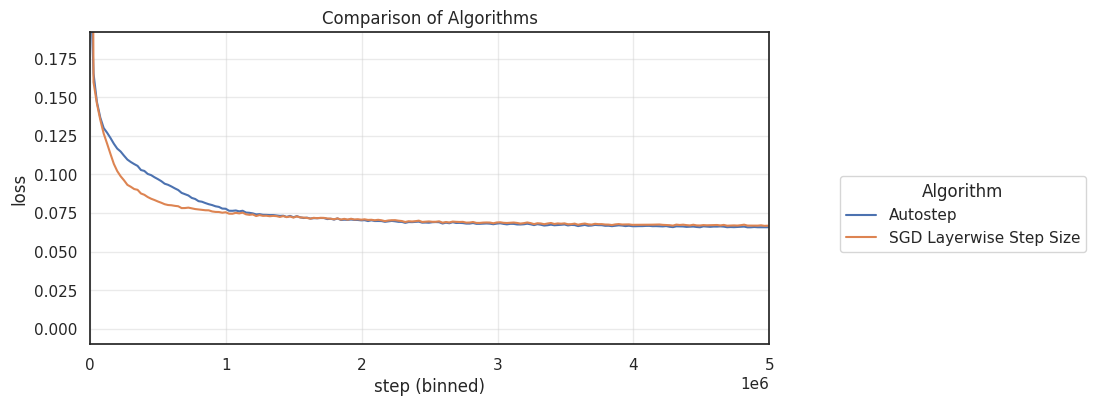

In [ ]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'sgd_layerwise_step_size': 'SGD Layerwise Step Size',
    'autostep': 'Autostep',
}

# Only keep rows whose sweep_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

combined_config_df['model_structure'] = (
    combined_config_df['model.n_layers'].astype(str) + ' layers | ' +
    combined_config_df['model.activation']
)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms')
plt.show()
